# Cellpose Cell Segmentation & Fluorescence Analysis

Segments cells on a **reference channel** using Cellpose, applies the resulting masks to both the reference and signal channels, and computes per-cell mean fluorescence intensities and their ratio.

**Outputs:**
1. Bar graph — per-image mean `cellF_ratio` (control vs drug), with SEM, individual data points, and Mann-Whitney significance
2. Scatter plot — all individual `cellF_sig` vs `cellF_ref` values for every cell across all images
3. Violin plot — distribution of all individual `cellF_ratio` values, with Mann-Whitney significance

In [1]:
import os
import glob
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage, stats
from cellpose import models
from cellpose.utils import masks_to_outlines
import pandas as pd

print("All imports successful.")

All imports successful.


In [2]:
# ─────────────────────────────────────────────
#  CONFIGURATION
#  1. Select your Control and Drug folders using the pickers.
#  2. Click 'Confirm folders'.
#  This cell will PAUSE until you confirm — subsequent cells won't run.
# ─────────────────────────────────────────────

import subprocess, sys, asyncio
try:
    import ipyfilechooser
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ipyfilechooser', '-q'])

from ipyfilechooser import FileChooser
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Path variables — set by the Confirm button ───────────────────────────────
CONTROL_ROOT = None
DRUG_ROOT    = None
SAVE_DIR     = None

# ── Channel & Cellpose settings (edit here if needed) ────────────────────────
REF_SUFFIX         = '_CH2.tif'
SIG_SUFFIX         = '_CH4.tif'
CELLPOSE_MODEL     = 'cyto3'
CELL_DIAMETER      = 0
FLOW_THRESHOLD     = 0.4
CELLPROB_THRESHOLD = 0.0
USE_GPU            = True

# ── Widgets ───────────────────────────────────────────────────────────────────
fc_ctrl = FileChooser('/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data',
                      title='<b>Control root folder</b>', show_only_dirs=True)
fc_drug = FileChooser('/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data',
                      title='<b>Drug root folder</b>', show_only_dirs=True)

btn_confirm = widgets.Button(
    description='Confirm folders',
    button_style='success',
    disabled=True,
    icon='check'
)
out = widgets.Output()

# Grab the running event loop BEFORE yielding, so the callback can reach it
_loop = asyncio.get_event_loop()
_confirmed_event = asyncio.Event()

def _check_ready(*args):
    btn_confirm.disabled = not (fc_ctrl.selected_path and fc_drug.selected_path)

def _on_confirm(b):
    global CONTROL_ROOT, DRUG_ROOT, SAVE_DIR
    CONTROL_ROOT = fc_ctrl.selected_path
    DRUG_ROOT    = fc_drug.selected_path
    SAVE_DIR = os.path.join(
        os.path.commonpath([
            os.path.abspath(CONTROL_ROOT),
            os.path.abspath(DRUG_ROOT),
        ]),
        'RESULTS'
    )
    os.makedirs(SAVE_DIR, exist_ok=True)
    with out:
        clear_output()
        print('Paths confirmed! Continuing...')
        print('  Control : ' + CONTROL_ROOT)
        print('  Drug    : ' + DRUG_ROOT)
        print('  Save dir: ' + SAVE_DIR)
    # Signal the event loop from this callback thread
    _loop.call_soon_threadsafe(_confirmed_event.set)

fc_ctrl.register_callback(_check_ready)
fc_drug.register_callback(_check_ready)
btn_confirm.on_click(_on_confirm)

display(fc_ctrl, fc_drug, btn_confirm, out)

# Fully yield to the kernel event loop — unblocked only when button fires
await _confirmed_event.wait()


FileChooser(path='/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data', filename='', title='<b>Control root folder</b…

FileChooser(path='/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data', filename='', title='<b>Drug root folder</b>',…

Button(button_style='success', description='Confirm folders', disabled=True, icon='check', style=ButtonStyle()…

Output()

True

In [3]:
# ─────────────────────────────────────────────
#  HELPER FUNCTIONS
# ─────────────────────────────────────────────

def find_image_pairs(root_dir, ref_suffix, sig_suffix):
    """
    Recursively find all reference images under root_dir.
    Returns a list of (ref_path, sig_path) tuples where both files exist.
    """
    ref_files = sorted(glob.glob(os.path.join(root_dir, "**", f"*{ref_suffix}"), recursive=True))
    pairs = []
    for ref_path in ref_files:
        sig_path = ref_path.replace(ref_suffix, sig_suffix)
        if os.path.exists(sig_path):
            pairs.append((ref_path, sig_path))
        else:
            print(f"  [WARN] No matching signal file for: {ref_path}")
    return pairs


def load_channel_raw(path):
    """
    Load a .tif file and return a 2-D float32 image with ABSOLUTE pixel values.
    Original file is never modified.

    • Singleton dimensions are squeezed out.
    • RGB / multi-channel images are averaged to a single grayscale plane,
      preserving the original intensity scale.
    • No normalisation or rescaling is applied.
    """
    img = tifffile.imread(path).squeeze().astype(np.float32)

    if img.ndim == 3:
        if img.shape[0] <= 4:        # (C, H, W)
            img = img.mean(axis=0)
        elif img.shape[2] <= 4:      # (H, W, C)
            img = img.mean(axis=2)
        else:
            raise ValueError(
                f"Unexpected 3-D shape {img.shape} in {path}. "
                "Cannot determine channel axis."
            )
    elif img.ndim != 2:
        raise ValueError(f"Expected 2-D image after squeeze, got shape {img.shape} for {path}")

    return img   # float32, original intensity values — original file untouched


def to_8bit(img_raw):
    """
    Return a NEW uint8 copy of img_raw scaled 0-255. Used only for Cellpose input.
    The original img_raw array is never modified.
    """
    img = img_raw.copy()
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min) * 255.0
    else:
        img = np.zeros_like(img)
    return img.astype(np.uint8)


def run_cellpose(model, img_8bit):
    """
    Run Cellpose on a 2-D uint8 reference image.
    Returns (masks, flows, styles).
    """
    masks, flows, styles = model.eval(
        img_8bit,
        diameter=CELL_DIAMETER,
        channels=[0, 0],
        flow_threshold=FLOW_THRESHOLD,
        cellprob_threshold=CELLPROB_THRESHOLD,
    )
    return masks, flows, styles


def save_seg_npy(ref_path, img_8bit, masks, flows, styles):
    """
    Save Cellpose segmentation output in the standard _seg.npy format.
    File is written next to the reference image as <basename>_seg.npy.
    """
    base = os.path.splitext(ref_path)[0]
    outlines = masks_to_outlines(masks)
    seg_dict = {
        "img"      : img_8bit,
        "masks"    : masks,
        "outlines" : outlines,
        "flows"    : flows,
        "styles"   : styles,
        "filename" : ref_path,
    }
    out_path = base + "_seg.npy"
    np.save(out_path, seg_dict)
    return out_path


def save_mask_overlay_png(ref_path, img_ref_raw, masks):
    """
    Save a PNG showing the reference channel image with coloured cell outlines
    overlaid. Saved next to the reference image as <basename>_overlay.png.
    Original image files are never modified.
    """
    base   = os.path.splitext(ref_path)[0]
    out_path = base + "_overlay.png"

    outlines = masks_to_outlines(masks)

    # Display image with percentile-based contrast (for visibility only)
    p_low, p_high = np.percentile(img_ref_raw, (1, 99))
    img_display = np.clip((img_ref_raw - p_low) / (p_high - p_low + 1e-6), 0, 1)

    fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
    ax.imshow(img_display, cmap="gray", interpolation="nearest")

    # Colour-coded cell mask overlay (semi-transparent)
    if masks.max() > 0:
        mask_rgb = plt.cm.tab20(masks % 20)          # cycle 20 colours
        mask_rgb[masks == 0] = [0, 0, 0, 0]          # background transparent
        mask_rgb[..., 3] = np.where(masks > 0, 0.3, 0)  # 30% opacity fill
        ax.imshow(mask_rgb, interpolation="nearest")

        # White outlines on top
        outline_overlay = np.zeros((*outlines.shape, 4), dtype=np.float32)
        outline_overlay[outlines] = [1, 1, 1, 0.9]
        ax.imshow(outline_overlay, interpolation="nearest")

    n_cells = int(masks.max())
    ax.set_title(f"{os.path.basename(ref_path)}  |  {n_cells} cells", fontsize=9)
    ax.axis("off")
    plt.tight_layout(pad=0.5)
    plt.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    return out_path


def extract_cell_fluorescence(mask, img_ref_raw, img_sig_raw):
    """
    For each labelled cell in mask, compute mean fluorescence using the
    ABSOLUTE (raw float32) pixel values of both channels.
    Returns arrays: cellF_ref, cellF_sig, cellF_ratio  (one value per cell).
    Cells with zero mean in ref are skipped to avoid division by zero.
    """
    cell_ids = np.unique(mask)
    cell_ids = cell_ids[cell_ids > 0]

    cellF_ref, cellF_sig, cellF_ratio = [], [], []
    for cid in cell_ids:
        px = mask == cid
        f_ref = img_ref_raw[px].mean()
        f_sig = img_sig_raw[px].mean()
        if f_ref == 0:
            continue
        cellF_ref.append(f_ref)
        cellF_sig.append(f_sig)
        cellF_ratio.append(f_sig / f_ref)

    return (np.array(cellF_ref, dtype=np.float32),
            np.array(cellF_sig, dtype=np.float32),
            np.array(cellF_ratio, dtype=np.float32))


def sig_stars(p):
    if p < 0.001:  return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else:          return "ns"


print("Helper functions defined.")

Helper functions defined.


In [4]:
# ─────────────────────────────────────────────
#  MAIN PROCESSING LOOP
# ─────────────────────────────────────────────

cp_model = models.CellposeModel(model_type=CELLPOSE_MODEL, gpu=USE_GPU)
print(f"Cellpose model '{CELLPOSE_MODEL}' loaded (GPU={USE_GPU}).\n")

results      = {}
per_cell_rows = []   # one row per cell  → Excel "per-cell" sheet
per_image_rows = []  # one row per image → Excel "per-image" sheet

for group_label, root in [("control", CONTROL_ROOT), ("drug", DRUG_ROOT)]:
    print(f"{'='*50}")
    print(f"Processing group: {group_label.upper()}  |  {root}")

    pairs = find_image_pairs(root, REF_SUFFIX, SIG_SUFFIX)
    print(f"Found {len(pairs)} image pair(s).\n")

    img_means = []
    all_ref, all_sig, all_ratio = [], [], []

    for idx, (ref_path, sig_path) in enumerate(pairs):
        img_name = os.path.basename(ref_path)
        print(f"  [{idx+1}/{len(pairs)}] {img_name}", end=" ... ")

        # ── Load raw float32 (absolute values, original files untouched) ────
        img_ref_raw = load_channel_raw(ref_path)
        img_sig_raw = load_channel_raw(sig_path)

        # ── 8-bit copy for Cellpose only ─────────────────────────────────────
        img_ref_8bit = to_8bit(img_ref_raw)

        # ── Run Cellpose ──────────────────────────────────────────────────────
        masks, flows, styles = run_cellpose(cp_model, img_ref_8bit)
        n_cells = int(masks.max())
        print(f"{n_cells} cells detected", end=" ... ")

        # ── Save _seg.npy next to the reference image ─────────────────────────
        seg_path = save_seg_npy(ref_path, img_ref_8bit, masks, flows, styles)

        # ── Save overlay PNG next to the reference image ──────────────────────
        overlay_path = save_mask_overlay_png(ref_path, img_ref_raw, masks)
        print(f"saved seg + overlay.")

        # ── Quantify fluorescence from raw absolute images ────────────────────
        cellF_ref, cellF_sig, cellF_ratio = extract_cell_fluorescence(
            masks, img_ref_raw, img_sig_raw
        )
        n_valid = len(cellF_ratio)

        if n_valid > 0:
            img_means.append(float(cellF_ratio.mean()))
            all_ref.extend(cellF_ref.tolist())
            all_sig.extend(cellF_sig.tolist())
            all_ratio.extend(cellF_ratio.tolist())

            # Per-cell rows for Excel
            for i in range(n_valid):
                per_cell_rows.append({
                    "group"        : group_label,
                    "image_file"   : img_name,
                    "image_path"   : ref_path,
                    "cell_id"      : i + 1,
                    "cellF_ref"    : float(cellF_ref[i]),
                    "cellF_sig"    : float(cellF_sig[i]),
                    "cellF_ratio"  : float(cellF_ratio[i]),
                })

            # Per-image row for Excel
            per_image_rows.append({
                "group"              : group_label,
                "image_file"         : img_name,
                "image_path"         : ref_path,
                "n_cells_detected"   : n_cells,
                "n_cells_valid"      : n_valid,
                "mean_cellF_ref"     : float(cellF_ref.mean()),
                "mean_cellF_sig"     : float(cellF_sig.mean()),
                "mean_cellF_ratio"   : float(cellF_ratio.mean()),
                "sem_cellF_ratio"    : float(cellF_ratio.std(ddof=1) / np.sqrt(n_valid))
                                       if n_valid > 1 else float("nan"),
                "seg_npy_path"       : seg_path,
                "overlay_png_path"   : overlay_path,
            })

    results[group_label] = {
        "img_means" : np.array(img_means),
        "all_ref"   : np.array(all_ref),
        "all_sig"   : np.array(all_sig),
        "all_ratio" : np.array(all_ratio),
    }
    print(f"\n  → {len(img_means)} images | {len(all_ratio)} total cells\n")

print("All processing complete.")

model_type argument is not used in v4.0.1+. Ignoring this argument...
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


Cellpose model 'cyto3' loaded (GPU=True).

Processing group: CONTROL  |  /Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/Shreedevi_CaST_construct2/control
Found 5 image pair(s).

  [1/5] SR2_C+_CH2.tif ... 

/opt/miniconda3/envs/cellpose/lib/python3.10/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


110 cells detected ... 

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


...

saved seg + overlay.
  [3/5] SR2_C+_CH2.tif ... 61 cells detected ... 

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


saved seg + overlay.
  [4/5] SR2_C+_CH2.tif ... 69 cells detected ... 

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


saved seg + overlay.
  [5/5] SR2_C+_CH2.tif ... 117 cells detected ... saved seg + overlay.

  → 5 images | 460 total cells

All processing complete.


In [5]:
# ─────────────────────────────────────────────
#  EXPORT TO EXCEL
#  Saved in the same folder as this notebook.
#  Sheet 1 — per_cell  : one row per cell (all groups)
#  Sheet 2 — per_image : one row per image (summary stats)
# ─────────────────────────────────────────────

excel_path = os.path.join(SAVE_DIR, "cellpose_results.xlsx")

df_cells  = pd.DataFrame(per_cell_rows)
df_images = pd.DataFrame(per_image_rows)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    df_cells.to_excel(writer,  sheet_name="per_cell",  index=False)
    df_images.to_excel(writer, sheet_name="per_image", index=False)

print(f"Excel saved: {excel_path}")
print(f"  per_cell  sheet : {len(df_cells)} rows")
print(f"  per_image sheet : {len(df_images)} rows")
df_images.head()

Excel saved: /Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/Shreedevi_CaST_construct2/RESULTS/cellpose_results.xlsx
  per_cell  sheet : 958 rows
  per_image sheet : 10 rows


,group,image_file,image_path,n_cells_detected,n_cells_valid,mean_cellF_ref,mean_cellF_sig,mean_cellF_ratio,sem_cellF_ratio,seg_npy_path,overlay_png_path
0,control,SR2_C+_CH2.tif,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,110,110,17.294073,2.651955,0.149792,0.005666,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...
1,control,SR2_C+_CH2.tif,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,101,101,15.570035,2.692131,0.165171,0.006005,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...
2,control,SR2_C+_CH2.tif,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,85,85,16.256384,2.714413,0.159347,0.005569,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...
3,control,SR2_C+_CH2.tif,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,50,50,19.525946,3.245558,0.161031,0.006539,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...
4,control,SR2_C+_CH2.tif,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,152,152,16.539576,2.747503,0.167650,0.005143,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...,/Users/ckk/Desktop/Cellpose_ClaudeAgent/Data/S...


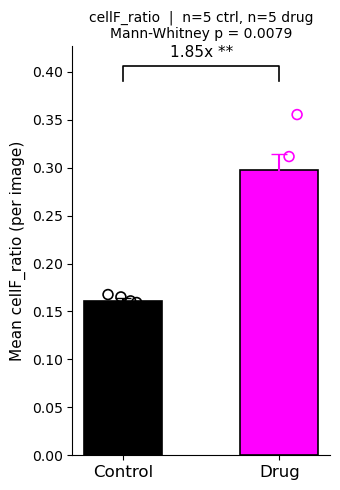

Fold change (drug/ctrl): 1.854x
Saved: fig1_bar_cellF_ratio.svg


In [6]:
# ─────────────────────────────────────────────
#  FIGURE 1 — Bar graph: per-image mean cellF_ratio
#  n = number of images per group
#  Error bars = SEM | nonparametric test = Mann-Whitney U
# ─────────────────────────────────────────────

ctrl_means = results["control"]["img_means"]
drug_means = results["drug"]["img_means"]

ctrl_mean, ctrl_sem = ctrl_means.mean(), ctrl_means.std(ddof=1) / np.sqrt(len(ctrl_means))
drug_mean, drug_sem = drug_means.mean(), drug_means.std(ddof=1) / np.sqrt(len(drug_means))

stat, p_bar = stats.mannwhitneyu(ctrl_means, drug_means, alternative="two-sided")
fold_change = drug_mean / ctrl_mean

fig, ax = plt.subplots(figsize=(3.5, 5))

# Bars
bar_kw = dict(width=0.5, edgecolor="black", linewidth=1.2, zorder=2)
ax.bar(0, ctrl_mean, color="black",   **bar_kw)
ax.bar(1, drug_mean, color="magenta", **bar_kw)

# SEM error bars
ax.errorbar(0, ctrl_mean, yerr=ctrl_sem, fmt="none", color="black",   capsize=6, linewidth=1.5, zorder=3)
ax.errorbar(1, drug_mean, yerr=drug_sem, fmt="none", color="magenta", capsize=6, linewidth=1.5, zorder=3)

# Individual data points (open circles, jittered slightly)
rng = np.random.default_rng(42)
jitter_ctrl = rng.uniform(-0.12, 0.12, size=len(ctrl_means))
jitter_drug = rng.uniform(-0.12, 0.12, size=len(drug_means))
ax.scatter(0 + jitter_ctrl, ctrl_means, s=50, facecolors="none", edgecolors="black",   linewidth=1.2, zorder=4)
ax.scatter(1 + jitter_drug, drug_means, s=50, facecolors="none", edgecolors="magenta", linewidth=1.2, zorder=4)

# Significance bracket + fold change + stars
stars = sig_stars(p_bar)
y_top = max(ctrl_mean + ctrl_sem, drug_mean + drug_sem,
            ctrl_means.max(), drug_means.max()) * 1.10
h = y_top * 0.04

ax.plot([0, 0, 1, 1], [y_top, y_top + h, y_top + h, y_top], lw=1.2, color="black")
ax.text(0.5, y_top + h * 1.4, str(round(fold_change, 2)) + "x " + stars,
        ha="center", va="bottom", fontsize=11,
        color="black" if stars != "ns" else "gray")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Control", "Drug"], fontsize=12)
ax.set_ylabel("Mean cellF_ratio (per image)", fontsize=11)
ax.set_title(
    "cellF_ratio  |  n=" + str(len(ctrl_means)) + " ctrl, n=" + str(len(drug_means)) + " drug\n"
    "Mann-Whitney p = " + str(round(p_bar, 4)),
    fontsize=10
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(os.path.join(SAVE_DIR,"fig1_bar_cellF_ratio.svg"), format='svg', bbox_inches="tight")
plt.show()
print("Fold change (drug/ctrl): " + str(round(fold_change, 3)) + "x")
print("Saved: fig1_bar_cellF_ratio.svg")

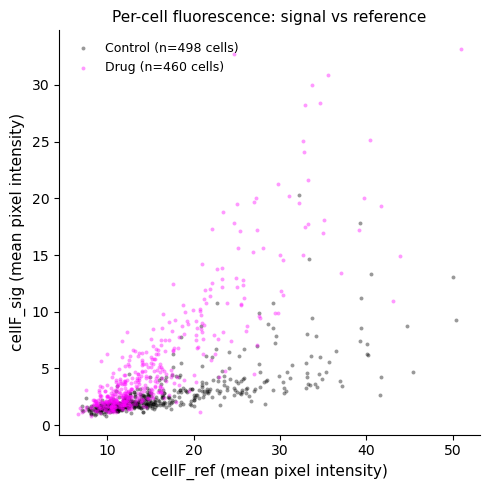

Saved: fig2_scatter_sig_vs_ref.svg


In [7]:
# ─────────────────────────────────────────────
#  FIGURE 2 — Scatter plot: cellF_sig vs cellF_ref
#  All individual cells from all images
#  Control = black dots | Drug = magenta dots
# ─────────────────────────────────────────────

ctrl_ref = results["control"]["all_ref"]
ctrl_sig = results["control"]["all_sig"]
drug_ref = results["drug"]["all_ref"]
drug_sig = results["drug"]["all_sig"]

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(ctrl_ref, ctrl_sig, s=8, alpha=0.4, color="black",   label=f"Control (n={len(ctrl_ref)} cells)", linewidths=0)
ax.scatter(drug_ref, drug_sig, s=8, alpha=0.4, color="magenta", label=f"Drug (n={len(drug_ref)} cells)",    linewidths=0)

ax.set_xlabel("cellF_ref (mean pixel intensity)", fontsize=11)
ax.set_ylabel("cellF_sig (mean pixel intensity)", fontsize=11)
ax.set_title("Per-cell fluorescence: signal vs reference", fontsize=11)
ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(os.path.join(SAVE_DIR,"fig2_scatter_sig_vs_ref.svg"), format='svg', bbox_inches="tight")
plt.show()
print("Saved: fig2_scatter_sig_vs_ref.svg")

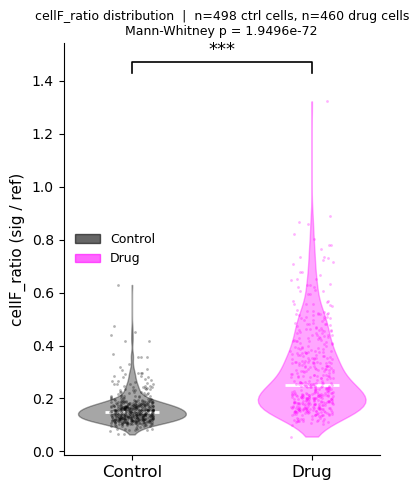

Saved: fig3_violin_cellF_ratio.svg


In [8]:
# ─────────────────────────────────────────────
#  FIGURE 3 — Violin plot: distribution of cellF_ratio
#  All individual cells from all images
#  Mann-Whitney U on the two full distributions
# ─────────────────────────────────────────────

ctrl_ratio = results["control"]["all_ratio"]
drug_ratio = results["drug"]["all_ratio"]

stat_v, p_violin = stats.mannwhitneyu(ctrl_ratio, drug_ratio, alternative="two-sided")

fig, ax = plt.subplots(figsize=(4, 5))

data   = [ctrl_ratio, drug_ratio]
colors = ["black", "magenta"]
labels = ["Control", "Drug"]
positions = [0, 1]

# Violin
parts = ax.violinplot(data, positions=positions, showmedians=True,
                      showextrema=False, widths=0.6)
for body, col in zip(parts["bodies"], colors):
    body.set_facecolor(col)
    body.set_edgecolor(col)
    body.set_alpha(0.35)
parts["cmedians"].set_color("white")
parts["cmedians"].set_linewidth(2)

# Individual data points (jittered)
rng = np.random.default_rng(99)
for pos, arr, col in zip(positions, data, colors):
    jitter = rng.uniform(-0.12, 0.12, size=len(arr))
    ax.scatter(pos + jitter, arr, s=4, alpha=0.3, color=col, linewidths=0, zorder=3)

# Significance annotation
stars_v = sig_stars(p_violin)
y_top = max(ctrl_ratio.max(), drug_ratio.max()) * 1.08
h = y_top * 0.03
ax.plot([0, 0, 1, 1], [y_top, y_top + h, y_top + h, y_top], lw=1.2, color="black")
ax.text(0.5, y_top + h * 1.3, stars_v, ha="center", va="bottom", fontsize=13,
        color="black" if stars_v != "ns" else "gray")

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("cellF_ratio (sig / ref)", fontsize=11)
ax.set_title(
    f"cellF_ratio distribution  |  "
    f"n={len(ctrl_ratio)} ctrl cells, n={len(drug_ratio)} drug cells\n"
    f"Mann-Whitney p = {p_violin:.4e}",
    fontsize=9
)
ax.spines[["top", "right"]].set_visible(False)

# Legend patches
patches = [mpatches.Patch(color=c, alpha=0.6, label=l) for c, l in zip(colors, labels)]
ax.legend(handles=patches, fontsize=9, frameon=False)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig(os.path.join(SAVE_DIR,"fig3_violin_cellF_ratio.svg"), format='svg', bbox_inches="tight")
plt.show()
print("Saved: fig3_violin_cellF_ratio.svg")